# CSCN8020 Assignment 3

## Deep Q-Network Control of the Unitree G1 Left Elbow

**Student:** Viraj Dipakkumar Mistry  
**Student ID:** 9088985  
**Repository:** <https://github.com/vir33mistry/CSCN8020_Assignment3>  
**Clone URL:** <https://github.com/vir33mistry/CSCN8020_Assignment3.git>

This notebook documents the complete student-written PyTorch DQN workflow:
environment validation, baseline evidence, network and replay implementation,
controlled exploration-decay experiments, greedy multi-goal evaluation,
rule-based comparison, plots, checkpoint loading, interpretation, and
reproducibility.

## 1. Imports, paths, and reproducibility

The final run uses Python 3.12, CPU execution, seed 8020, Gymnasium 1.3.0,
MuJoCo 3.10.0, and PyTorch 2.7.1. All commands assume that the notebook is
opened from the repository root.

In [1]:
from pathlib import Path
import json
import random
import sys

import gymnasium as gym
from gymnasium.utils.env_checker import check_env
from IPython.display import Image, Video, display
import matplotlib.pyplot as plt
import mujoco
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").is_dir():
    raise RuntimeError("Open this notebook from the CSCN8020_Assignment3 repository root.")

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from dqn import DQNAgent, DQNHyperparameters, QNetwork, ReplayBuffer
from dqn.experiment import BENCHMARK_GOALS, set_reproducible_seeds
from g1_rl import G1ElbowTargetEnv
from test_g1_elbow_env import choose_rule_based_action

SEED = 8020
set_reproducible_seeds(SEED)

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Gymnasium:", gym.__version__)
print("MuJoCo:", mujoco.__version__)
print("Device: cpu")

Python: 3.12.13
PyTorch: 2.7.1+cpu
Gymnasium: 1.3.0
MuJoCo: 3.10.0
Device: cpu


## 2. Approved reinforcement-learning task

The approved environment is not redesigned.

| Component | Definition |
|---|---|
| Observation | `[elbow angle, angular velocity, goal, goal - angle]` |
| Action 0 | Decrease the internal controller target |
| Action 1 | Hold the internal controller target |
| Action 2 | Increase the internal controller target |
| Training goals | Uniform samples from `[-0.8, +0.8]` rad |
| Success | Error at most 0.04 rad for 8 consecutive environment steps |
| Termination | Task success |
| Truncation | 150-step time limit |
| Low-level control | Approved PD controller plus MuJoCo bias compensation |

The DQN chooses a discrete target adjustment. The low-level controller converts
that target into bounded actuator torque. This separation lets the agent learn
high-level decisions without relearning deterministic gravity compensation.

In [2]:
environment = G1ElbowTargetEnv(
    goal_angle=None,
    goal_range=(-0.8, 0.8),
)
check_env(environment, skip_render_check=True)
observation, info = environment.reset(
    seed=SEED,
    options={"goal_angle": -0.8},
)

print("Environment checker passed.")
print("Observation:", observation)
print("Observation shape:", environment.observation_space.shape)
print("Action count:", environment.action_space.n)
print("Controlled joint:", environment.CONTROLLED_JOINT)
print("Controlled actuator:", environment.CONTROLLED_ACTUATOR)
environment.close()

Environment checker passed.
Observation: [ 0.   0.  -0.8 -0.8]
Observation shape: (4,)
Action count: 3
Controlled joint: left_elbow_joint
Controlled actuator: left_elbow


## 3. Rule-based baseline before training

The assignment requires a validated baseline before DQN training. The same four
goals and five episodes per goal are used for all policies.

In [3]:
baseline_by_goal = pd.read_csv(
    PROJECT_ROOT / "results/baseline/summary_by_goal.csv"
)
baseline_summary = json.loads(
    (PROJECT_ROOT / "results/baseline/summary.json").read_text()
)

display(baseline_by_goal)
print(
    f"Overall baseline: {baseline_summary['successes']}/"
    f"{baseline_summary['episodes']} successes "
    f"({baseline_summary['success_rate']:.0%})"
)

Overall baseline: 20/20 successes (100%)


,goal_angle,episodes,successes,success_rate,mean_reward,mean_episode_length,mean_final_absolute_error
0,-0.8,5,5,1.0,10.521528,27.0,0.012328
1,-0.4,5,5,1.0,15.214057,21.0,0.013217
2,0.4,5,5,1.0,15.211075,21.0,0.012720
3,0.8,5,5,1.0,10.519857,27.0,0.010571


## 4. Student-written Q-network

The required architecture is `4 -> 64 ReLU -> 64 ReLU -> 3`. The final layer
does not use softmax because DQN outputs unconstrained expected returns, not
probabilities. The online and target networks have the same architecture but
separate parameters.

In [4]:
network = QNetwork(
    observation_size=4,
    action_size=3,
    hidden_size=64,
)
sample_output = network(torch.zeros((2, 4)))

print(network)
print("Output shape for two observations:", tuple(sample_output.shape))
print(
    "Contains softmax:",
    any(isinstance(module, torch.nn.Softmax) for module in network.modules()),
)

QNetwork(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)
Output shape for two observations: (2, 3)
Contains softmax: False


## 5. Experience replay and Bellman optimization

Each replay transition stores `(state, action, reward, next_state, terminated,
truncated)`. Capacity is 50,000, training starts after 500 transitions, and
mini-batches contain 64 randomly sampled transitions.

The target is:

$$
y = r + \gamma (1-\text{terminated})\max_{a'}Q_{target}(s',a')
$$

where $\gamma=0.95$. Episodes stop on either ending signal. Only a true
termination blocks bootstrapping; a time-limit truncation is stored explicitly
but its final physical state remains non-terminal for the Bellman target.
Huber loss, Adam, gradient clipping, and target synchronization every 250
optimization steps stabilize learning.

In [5]:
buffer = ReplayBuffer(capacity=70, seed=SEED)
for index in range(80):
    state = np.array([index / 100, 0.0, 0.4, 0.4 - index / 100], dtype=np.float32)
    buffer.push(
        state=state,
        action=index % 3,
        reward=-abs(float(state[3])),
        next_state=state + 0.001,
        terminated=(index % 31 == 0),
        truncated=(index % 47 == 0),
    )

batch = buffer.sample(64).to_tensors(torch.device("cpu"))
print("Bounded replay size:", len(buffer))
print("State batch:", tuple(batch.states.shape))
print("Action batch:", tuple(batch.actions.shape))
print("Terminal dtype:", batch.terminated.dtype)

Bounded replay size: 70
State batch: (64, 4)
Action batch: (64, 1)
Terminal dtype: torch.bool


## 6. Controlled exploration-decay study

Both runs use 600 episodes, seed 8020, CPU, gamma 0.95, learning rate 0.001,
batch size 64, replay capacity 50,000, epsilon 1.0 to 0.05, 500-transition
warm-up, and 250-step target updates. Only epsilon decay differs:

- Configuration A: `0.995`
- Configuration B: `0.985`

Training is headless and contains a per-run time limit.

In [6]:
RUN_TRAINING = False

if RUN_TRAINING:
    import subprocess
    subprocess.run(
        [
            sys.executable,
            "src/train_dqn.py",
            "--config", "all",
            "--episodes", "600",
            "--device", "cpu",
            "--seed", str(SEED),
        ],
        check=True,
        env={**__import__("os").environ, "PYTHONPATH": "src"},
    )
else:
    print("Using submitted metrics and checkpoints. Set RUN_TRAINING=True to repeat both experiments.")

Using submitted metrics and checkpoints. Set RUN_TRAINING=True to repeat both experiments.


In [7]:
training_rows = []
for configuration in ("config_a", "config_b"):
    summary = json.loads(
        (
            PROJECT_ROOT
            / "results"
            / configuration
            / "training_summary.json"
        ).read_text()
    )
    training_rows.append(
        {
            "configuration": configuration,
            "episodes": summary["completed_episodes"],
            "time_seconds": summary["wall_clock_seconds"],
            "final_epsilon": summary["final_epsilon"],
            "final_20_mean_reward": summary["mean_reward_final_20"],
            "final_50_success_rate": summary["training_success_rate_final_50"],
            "optimization_steps": summary["total_optimization_steps"],
        }
    )

training_summary_table = pd.DataFrame(training_rows)
display(training_summary_table)

,configuration,episodes,time_seconds,final_epsilon,final_20_mean_reward,final_50_success_rate,optimization_steps
0,config_a,600,53.699159,0.05,15.556561,1.0,17512
1,config_b,600,40.003118,0.05,15.367680,1.0,12955


## 7. Required training plots

training_reward.png
training_success_rate.png
epsilon_decay.png
loss_curve.png
configuration_comparison.png


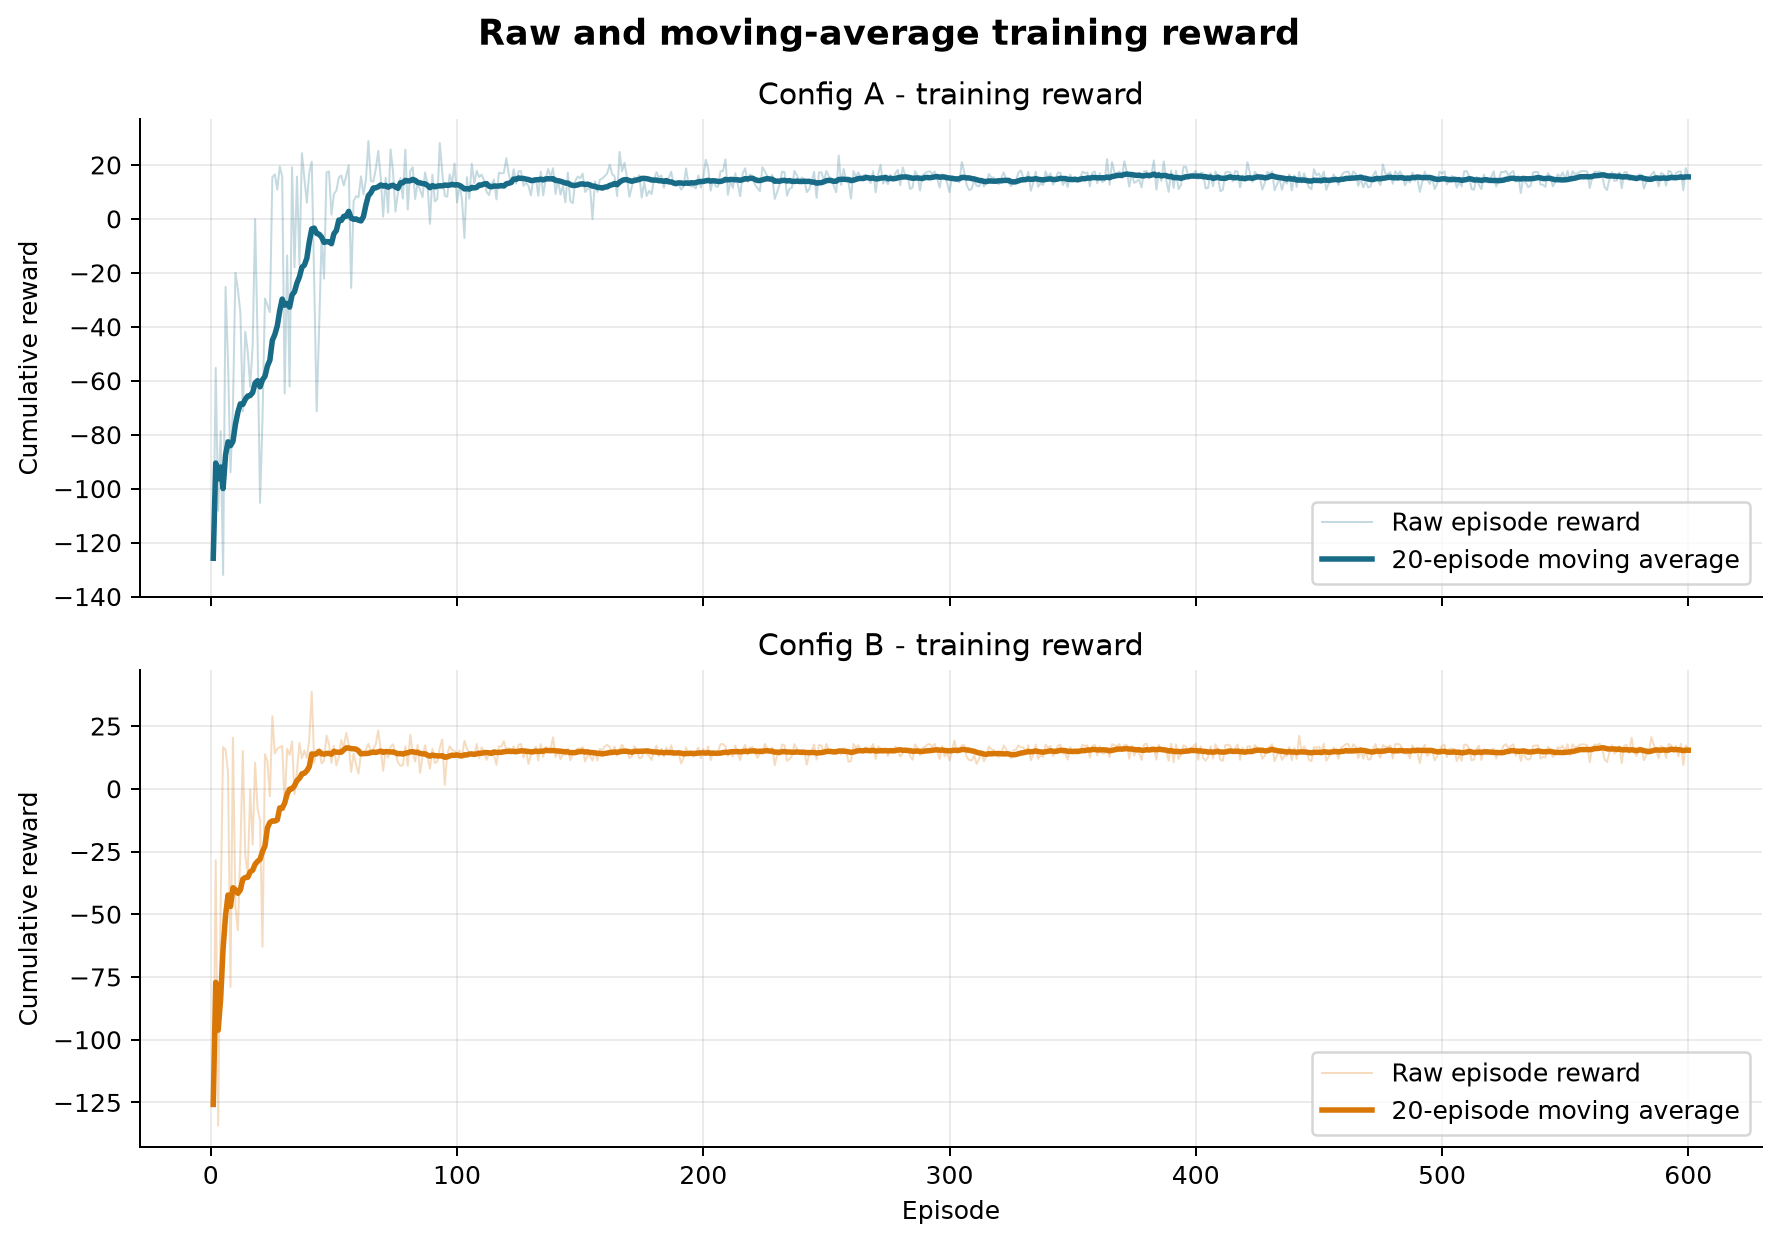

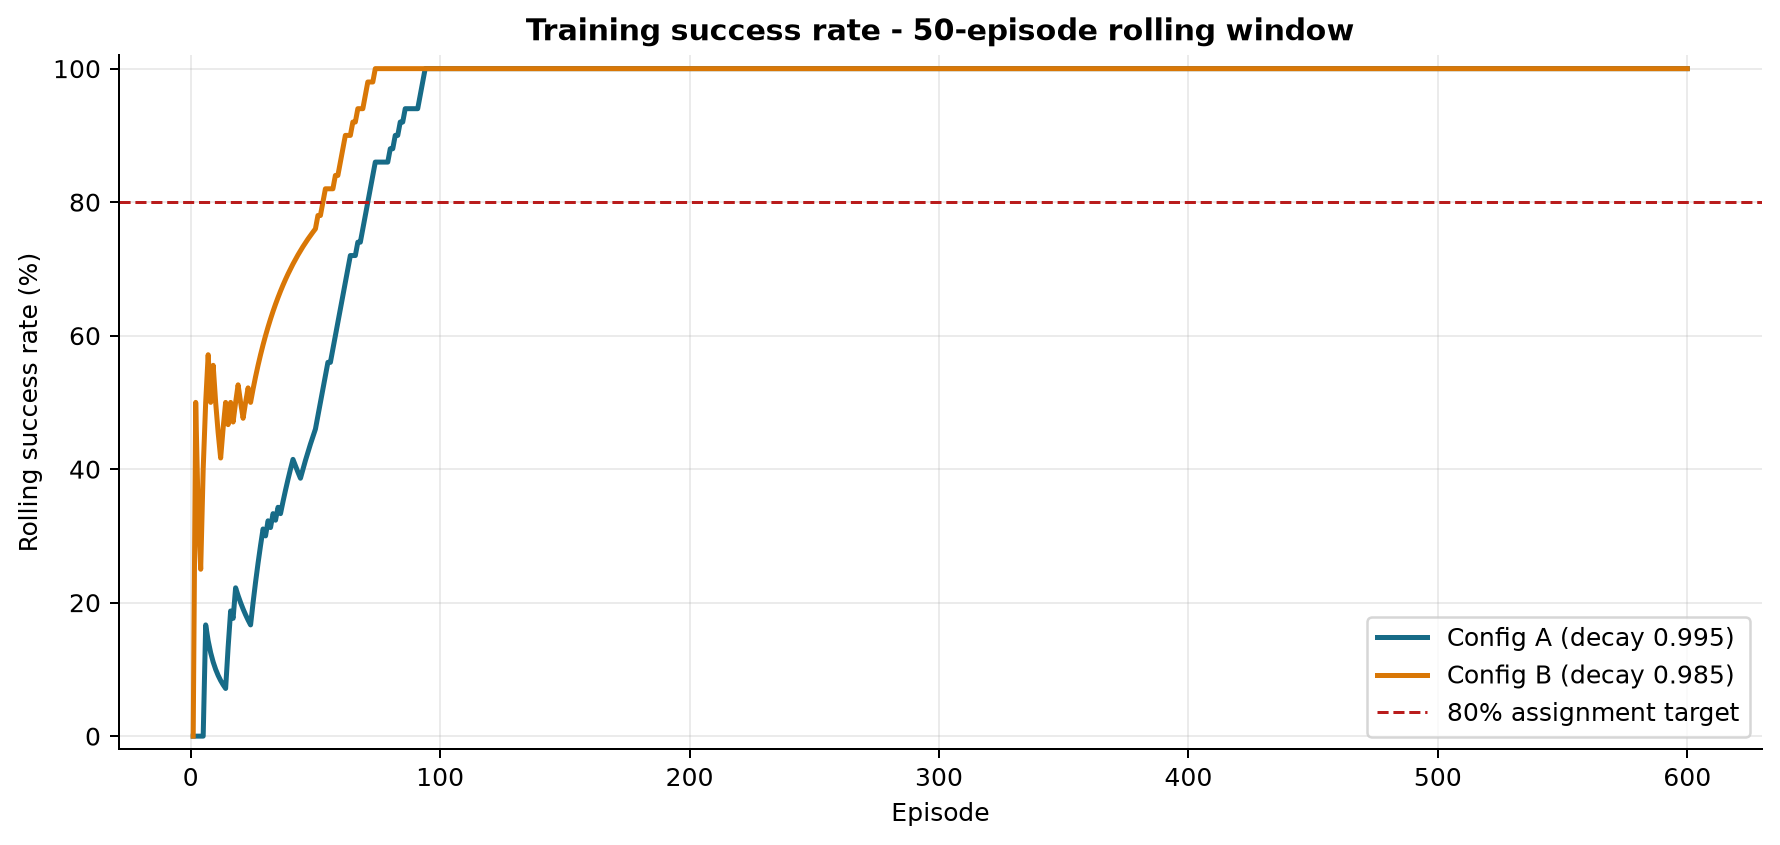

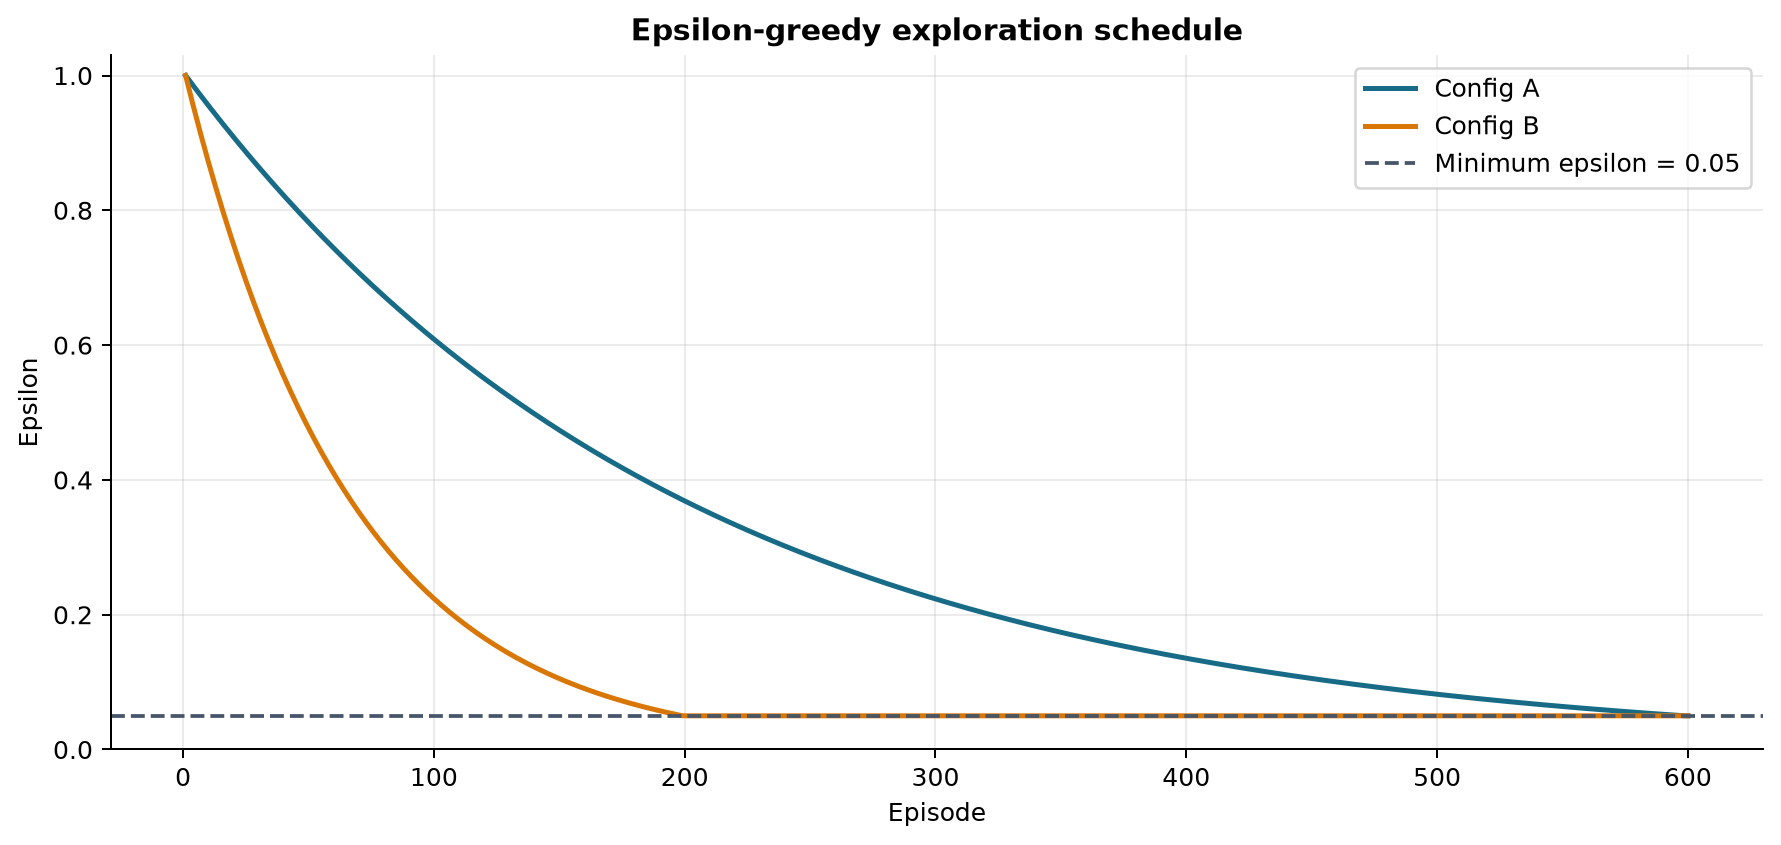

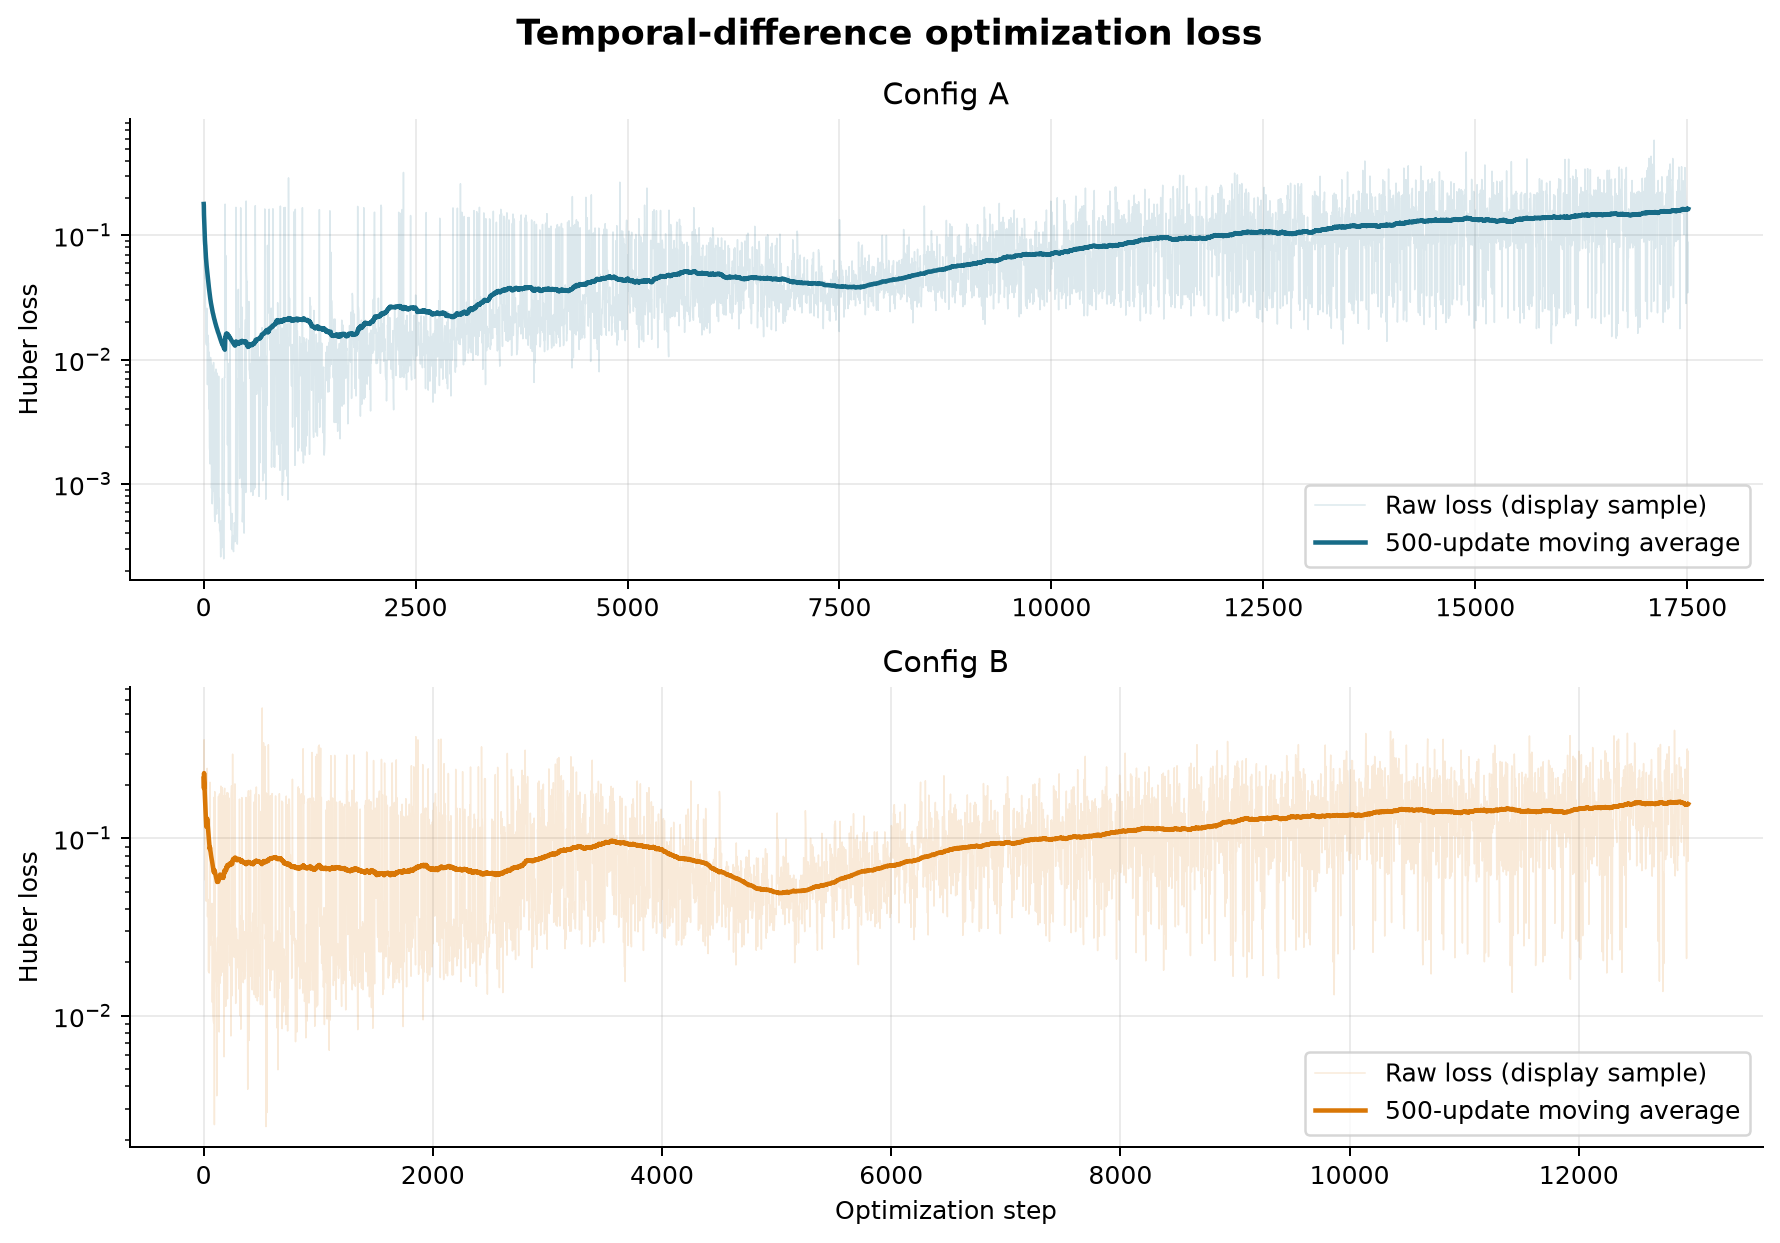

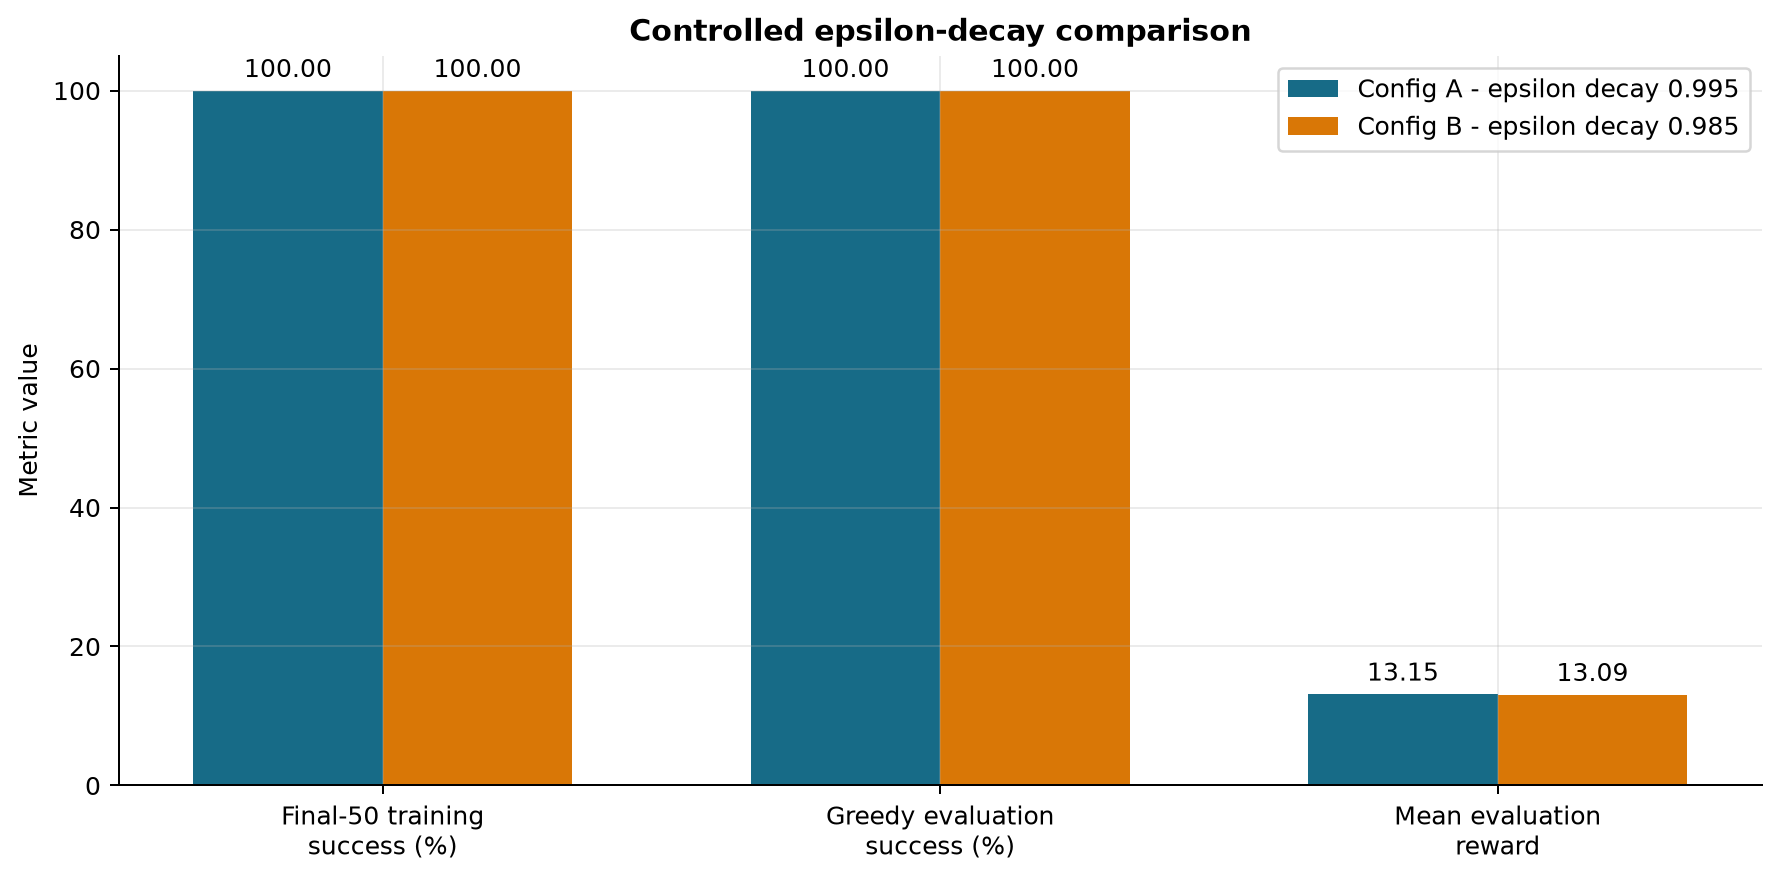

In [8]:
for plot_name in [
    "training_reward.png",
    "training_success_rate.png",
    "epsilon_decay.png",
    "loss_curve.png",
    "configuration_comparison.png",
]:
    print(plot_name)
    display(Image(filename=str(PROJECT_ROOT / "plots" / plot_name), width=900))

### Training interpretation

Both rolling success curves reach 100%. Configuration B reaches low exploration
earlier; Configuration A collects exploratory data longer. Huber loss is
non-monotonic because Q-target magnitudes and replay composition change as
terminal bonus transitions become frequent. The stable reward curves,
final-50 success rates, and independent greedy evaluation are stronger policy
evidence than loss alone.

## 8. Greedy 20-episode multi-goal evaluation

Evaluation loads each saved checkpoint, sets epsilon to `0.0`, and runs five
episodes at each required goal. Fixed common seeds make the comparison fair.

In [9]:
evaluation_by_goal = pd.read_csv(
    PROJECT_ROOT / "results/evaluation/config_a_by_goal.csv"
)
comparison = pd.read_csv(
    PROJECT_ROOT / "results/evaluation/policy_comparison.csv"
)
selection = json.loads(
    (
        PROJECT_ROOT
        / "results/evaluation/selection_summary.json"
    ).read_text()
)

display(evaluation_by_goal)
display(comparison)
print("Selected configuration:", selection["selected_configuration"])
print("Selected meets 80% threshold:", selection["selected_meets_threshold"])

Selected configuration: config_a
Selected meets 80% threshold: True


,goal_angle,episodes,successes,success_rate,mean_reward,mean_episode_length,mean_final_absolute_error,mean_hold_actions,mean_action_changes
0,-0.8,5,5,1.0,10.589848,25.0,0.009327,13.0,7.0
1,-0.4,5,5,1.0,15.503292,18.0,0.004992,11.0,5.0
2,0.4,5,5,1.0,15.517476,17.0,0.010201,6.0,9.0
3,0.8,5,5,1.0,10.988186,23.0,0.003854,9.0,6.0


,policy,successes_out_of_20,success_rate,mean_cumulative_reward,mean_episode_length,mean_final_absolute_error,hold_action_fraction,mean_action_changes
0,config_a,20,1.0,13.149701,20.75,0.007093,0.469880,6.75
1,config_b,20,1.0,13.087999,19.75,0.013579,0.113924,6.25
2,rule_based,20,1.0,12.866629,24.00,0.012209,0.687500,1.00


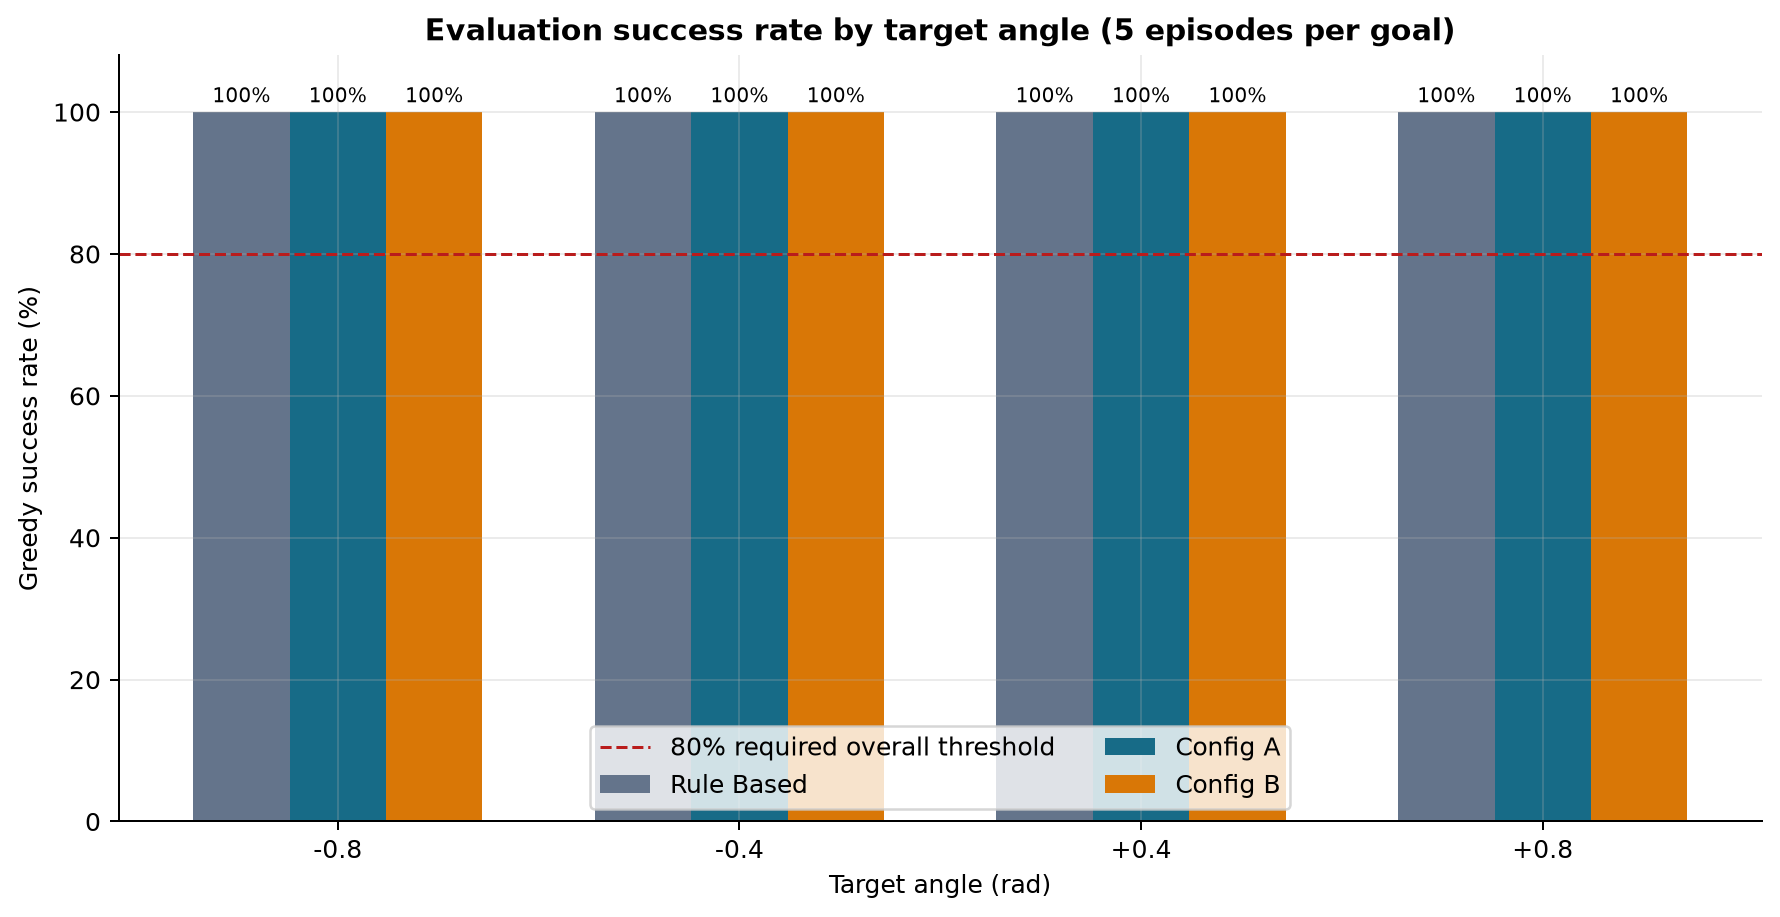

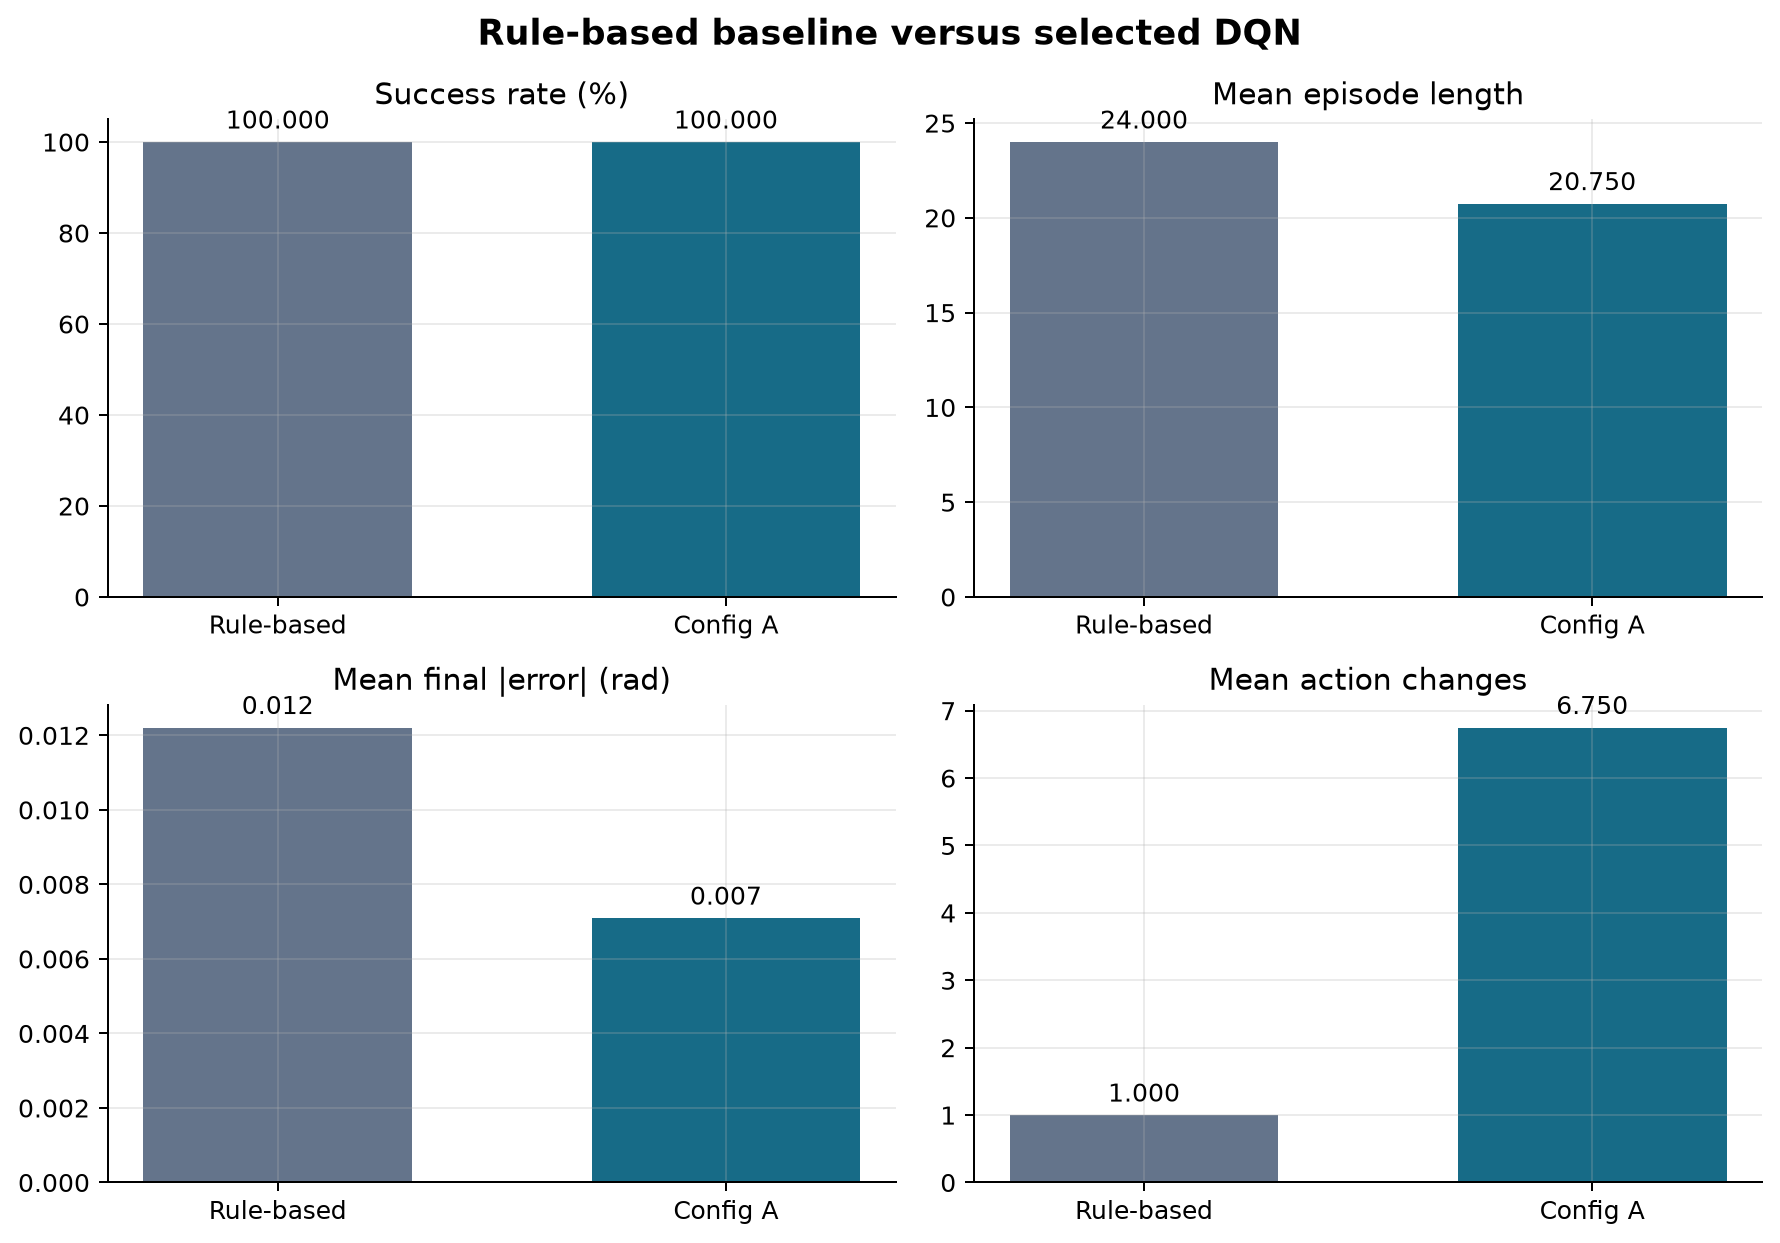

In [10]:
display(
    Image(
        filename=str(PROJECT_ROOT / "plots/evaluation_success_by_goal.png"),
        width=900,
    )
)
display(
    Image(
        filename=str(PROJECT_ROOT / "plots/rule_based_vs_selected_dqn.png"),
        width=900,
    )
)

## 9. Checkpoint loading and greedy action

The checkpoint is loaded on CPU without retraining. Its metadata identifies the
selected experiment and preserves all hyperparameters.

In [11]:
selected_agent, checkpoint_metadata = DQNAgent.load_checkpoint(
    PROJECT_ROOT / "models/selected_dqn.pt",
    device="cpu",
)
sample_state = np.array([0.0, 0.0, 0.4, 0.4], dtype=np.float32)

print("Checkpoint configuration:", checkpoint_metadata["configuration"])
print("Evaluation epsilon: 0.0")
print("Sample Q-values:", selected_agent.q_values(sample_state))
print("Greedy action:", selected_agent.greedy_action(sample_state))

Checkpoint configuration: config_a
Evaluation epsilon: 0.0
Sample Q-values: [6.2635374 7.3222923 8.150067 ]
Greedy action: 2


## 10. Rule-based versus DQN discussion

The rule-based policy is more sample efficient because it requires no training
and encodes the correct target direction. It is also more stable in action
space, averaging one action change versus 6.75 for selected DQN. The DQN,
however, succeeds at all four goals, finishes sooner, earns higher mean reward,
and reaches lower final error. Configuration A uses HOLD in 46.99% of actions,
showing that it learned to settle near goals, although it remains more
corrective than the baseline.

A hand-written policy can outperform learned behaviour on a simple deterministic
task because it starts with perfect structural knowledge. DQN's benefit is that
one network learns the multi-goal mapping from experience rather than receiving
an explicit target-update rule.

## 11. Recommendation, limitations, and conclusion

Configuration A is selected. Both policies achieve 100%, but A has higher
final-20 training reward, higher greedy mean reward, lower final absolute error,
and much greater HOLD use. Its small extra training time remains far below the
five-hour limit.

Limitations include one joint, fixed-base deterministic physics, one training
seed, 20 deterministic evaluation episodes, no disturbances, and more action
switching than the rule-based policy. Future work should repeat several seeds,
test denser unseen goals and perturbations, and evaluate approved extensions
such as Double DQN.

**Final result:** 20/20 greedy successes, 100% overall success, mean reward
13.1497, and mean final absolute error 0.0071 rad.

## 12. Saved-policy video and reproducibility

`video/selected_dqn_demo.mp4` is 2 minutes 15 seconds, loads
`models/selected_dqn.pt`, uses epsilon 0.0, and shows all four goals without
retraining. `src/render_dqn_policy.py` provides the interactive MuJoCo viewer
version for WSLg screen recording.

In [12]:
video_path = PROJECT_ROOT / "video/selected_dqn_demo.mp4"
print("Video exists:", video_path.is_file())
print("Video size (MB):", round(video_path.stat().st_size / 1_000_000, 2))
display(Video(filename=str(video_path), embed=False, width=900))

Video exists: True
Video size (MB): 1.78


## References and AI-use acknowledgement

1. Mnih et al. (2015), *Human-level control through deep reinforcement
   learning*, Nature 518, 529-533.
2. PyTorch, *Reinforcement Learning (DQN) Tutorial*.
3. Farama Foundation, *Handling Time Limits*.
4. Google DeepMind, *MuJoCo Python Documentation*.
5. CSCN8020 Assignment 3 specification and G1 Primer Workshop.

Generative AI assistance supported scaffolding, debugging, test design,
formatting, and draft writing. The student remains responsible for verifying
all outputs and understanding every submitted component.